<a href="https://www.kaggle.com/code/onikfardin/eaarly-2?scriptVersionId=334814424" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/surajsooraj26/iot-23/dataset19.csv
/kaggle/input/datasets/surajsooraj26/iot-23/dataset20.csv
/kaggle/input/datasets/surajsooraj26/iot-23/dataset15.csv
/kaggle/input/datasets/surajsooraj26/iot-23/dataset8.csv
/kaggle/input/datasets/surajsooraj26/iot-23/dataset16.csv
/kaggle/input/datasets/surajsooraj26/iot-23/dataset2.csv
/kaggle/input/datasets/surajsooraj26/iot-23/dataset11.csv
/kaggle/input/datasets/surajsooraj26/iot-23/dataset13.csv
/kaggle/input/datasets/surajsooraj26/iot-23/dataset10.csv
/kaggle/input/datasets/surajsooraj26/iot-23/dataset22.csv
/kaggle/input/datasets/surajsooraj26/iot-23/dataset4.csv
/kaggle/input/datasets/surajsooraj26/iot-23/dataset23.csv
/kaggle/input/datasets/surajsooraj26/iot-23/dataset18.csv
/kaggle/input/datasets/surajsooraj26/iot-23/dataset1.csv
/kaggle/input/datasets/surajsooraj26/iot-23/dataset17.csv
/kaggle/input/datasets/surajsooraj26/iot-23/dataset9.csv
/kaggle/input/datasets/surajsooraj26/iot-23/dataset7.csv
/kaggle/input/datase

In [2]:
# ============================================================
# CELL 1
# Import required libraries
# ============================================================

import os
import gc
import warnings

import numpy as np
import pandas as pd

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout
)
from tensorflow.keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt

# Ignore unnecessary warnings
warnings.filterwarnings("ignore")

# ============================================================
# Dataset Location
# ============================================================

DATASET_PATH = "/kaggle/input/datasets/surajsooraj26/iot-23"

# ============================================================
# Selected datasets
# ============================================================

# Mostly benign scenarios
BENIGN_FILES = [
    "dataset13.csv",
    "dataset20.csv",
    "dataset21.csv"
]

# Mostly attack scenarios
ATTACK_FILES = [
    "dataset6.csv",
    "dataset7.csv",
    "dataset8.csv"
]

print("Setup completed successfully.")

print("\nBenign datasets:")
print(BENIGN_FILES)

print("\nAttack datasets:")
print(ATTACK_FILES)

Setup completed successfully.

Benign datasets:
['dataset13.csv', 'dataset20.csv', 'dataset21.csv']

Attack datasets:
['dataset6.csv', 'dataset7.csv', 'dataset8.csv']


In [3]:
# ============================================================
# CELL 2
# Function to load and preprocess one IoT-23 dataset
# ============================================================

def process_dataset(file_name):
    """
    Loads one IoT-23 dataset and converts it into
    10-second behavioral windows.
    """

    # ----------------------------------------
    # Read CSV
    # ----------------------------------------
    file_path = os.path.join(DATASET_PATH, file_name)

    df = pd.read_csv(
        file_path,
        low_memory=False
    )

    # ----------------------------------------
    # Fix merged last column
    # ----------------------------------------
    merged_col = df.columns[-1]

    split = df[merged_col].str.split(r"\s{3,}", expand=True)

    df["tunnel_parents"] = split[0]
    df["label"] = split[1]
    df["detailed_label"] = split[2]

    df.drop(columns=[merged_col], inplace=True)

    # ----------------------------------------
    # Convert timestamp
    # ----------------------------------------
    df["ts"] = pd.to_datetime(df["ts"], unit="s")

    # ----------------------------------------
    # Binary target
    # ----------------------------------------
    df["attack"] = (df["label"] == "Malicious").astype(int)

    # ----------------------------------------
    # Convert numeric columns
    # ----------------------------------------
    numeric_columns = [
        "duration",
        "orig_bytes",
        "resp_bytes",
        "orig_pkts",
        "orig_ip_bytes",
        "resp_pkts",
        "resp_ip_bytes",
        "missed_bytes"
    ]

    for col in numeric_columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df[numeric_columns] = df[numeric_columns].fillna(0)

    # ----------------------------------------
    # Encode categorical columns
    # ----------------------------------------
    categorical_columns = [
        "proto",
        "service",
        "conn_state"
    ]

    for col in categorical_columns:
        encoder = LabelEncoder()
        df[col] = encoder.fit_transform(df[col].astype(str))

    # ----------------------------------------
    # Sort by timestamp
    # ----------------------------------------
    df = df.sort_values("ts").reset_index(drop=True)

    # ----------------------------------------
    # Create 10-second windows
    # ----------------------------------------
    df["window"] = df["ts"].dt.floor("10s")

    # ----------------------------------------
    # Aggregate features
    # ----------------------------------------
    window_df = (
        df.groupby("window")
        .agg(
            proto_mean=("proto", "mean"),
            service_mean=("service", "mean"),
            conn_state_mean=("conn_state", "mean"),
            duration_mean=("duration", "mean"),
            orig_bytes_mean=("orig_bytes", "mean"),
            resp_bytes_mean=("resp_bytes", "mean"),
            orig_pkts_mean=("orig_pkts", "mean"),
            resp_pkts_mean=("resp_pkts", "mean"),
            flow_count=("attack", "count"),
            attack=("attack", "max")
        )
        .reset_index()
    )

    # ----------------------------------------
    # Fill missing windows
    # ----------------------------------------
    full_time = pd.date_range(
        start=window_df["window"].min(),
        end=window_df["window"].max(),
        freq="10s"
    )

    window_df = (
        window_df
        .set_index("window")
        .reindex(full_time)
        .reset_index()
    )

    window_df.rename(
        columns={"index": "window"},
        inplace=True
    )

    feature_cols = [
        "proto_mean",
        "service_mean",
        "conn_state_mean",
        "duration_mean",
        "orig_bytes_mean",
        "resp_bytes_mean",
        "orig_pkts_mean",
        "resp_pkts_mean",
        "flow_count"
    ]

    window_df[feature_cols] = window_df[feature_cols].fillna(0)

    window_df["attack"] = (
        window_df["attack"]
        .fillna(0)
        .astype(int)
    )

    return window_df

In [4]:
# ============================================================
# CELL 3
# Process all selected IoT-23 datasets
# ============================================================

all_windows = []

selected_files = BENIGN_FILES + ATTACK_FILES

print("Processing datasets...\n")

for file in selected_files:

    print(f"Processing {file}...")

    window_df = process_dataset(file)

    # Keep the source dataset name
    window_df["dataset"] = file

    all_windows.append(window_df)

    print(f"Windows : {len(window_df):,}")
    print(f"Attack Windows : {window_df['attack'].sum():,}")
    print("-" * 40)

    # Free memory
    gc.collect()

# ------------------------------------------------------------
# Combine all processed datasets
# ------------------------------------------------------------

final_df = pd.concat(
    all_windows,
    ignore_index=True
)

print("\n======================================")
print("All datasets processed successfully.")
print("======================================")

print(f"\nTotal Windows : {len(final_df):,}")

print("\nAttack Distribution:")
print(final_df["attack"].value_counts())

display(final_df.head())

Processing datasets...

Processing dataset13.csv...
Windows : 3,006
Attack Windows : 3
----------------------------------------
Processing dataset20.csv...
Windows : 8,606
Attack Windows : 12
----------------------------------------
Processing dataset21.csv...
Windows : 8,635
Attack Windows : 13
----------------------------------------
Processing dataset6.csv...
Windows : 8,640
Attack Windows : 8,135
----------------------------------------
Processing dataset7.csv...
Windows : 8,636
Attack Windows : 134
----------------------------------------
Processing dataset8.csv...
Windows : 5,307
Attack Windows : 5,307
----------------------------------------

All datasets processed successfully.

Total Windows : 42,830

Attack Distribution:
attack
0    29226
1    13604
Name: count, dtype: int64


,window,proto_mean,service_mean,conn_state_mean,duration_mean,orig_bytes_mean,resp_bytes_mean,orig_pkts_mean,resp_pkts_mean,flow_count,attack,dataset
0,2019-01-10 13:34:40,0.4,2.000000,4.000000,24.385843,157.800000,31636.000000,62.600000,77.800000,5.0,1,dataset13.csv
1,2019-01-10 13:34:50,0.5,1.750000,4.500000,1.707956,66.500000,15868.750000,15.500000,13.750000,4.0,1,dataset13.csv
2,2019-01-10 13:35:00,0.0,0.000000,3.000000,0.000000,0.000000,0.000000,1.000000,0.000000,2.0,0,dataset13.csv
3,2019-01-10 13:35:10,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0,dataset13.csv
4,2019-01-10 13:35:20,0.5,2.214286,4.571429,1.280107,130.642857,14137.285714,15.071429,13.357143,14.0,1,dataset13.csv


In [5]:
# ============================================================
# CELL 4
# Normalize feature columns
# ============================================================

from sklearn.preprocessing import MinMaxScaler

# Feature columns (do NOT include target or identifiers)
feature_columns = [
    "proto_mean",
    "service_mean",
    "conn_state_mean",
    "duration_mean",
    "orig_bytes_mean",
    "resp_bytes_mean",
    "orig_pkts_mean",
    "resp_pkts_mean",
    "flow_count"
]

# Create scaler
scaler = MinMaxScaler()

# Normalize features
final_df[feature_columns] = scaler.fit_transform(final_df[feature_columns])

print("Normalization completed.")

display(final_df.head())

Normalization completed.


,window,proto_mean,service_mean,conn_state_mean,duration_mean,orig_bytes_mean,resp_bytes_mean,orig_pkts_mean,resp_pkts_mean,flow_count,attack,dataset
0,2019-01-10 13:34:40,0.20,0.666667,0.500000,0.000287,1.639741e-07,0.385349,9.480919e-07,0.008093,0.000041,1,dataset13.csv
1,2019-01-10 13:34:50,0.25,0.583333,0.562500,0.000020,6.910188e-08,0.193293,2.347512e-07,0.001430,0.000033,1,dataset13.csv
2,2019-01-10 13:35:00,0.00,0.000000,0.375000,0.000000,0.000000e+00,0.000000,1.514524e-08,0.000000,0.000016,0,dataset13.csv
3,2019-01-10 13:35:10,0.00,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0,dataset13.csv
4,2019-01-10 13:35:20,0.25,0.738095,0.571429,0.000015,1.357544e-07,0.172202,2.282604e-07,0.001389,0.000114,1,dataset13.csv


In [6]:
# ============================================================# ============================================================
# CELL 5 (UPDATED)
# Create LSTM sequences for 30-second early attack prediction
# ============================================================

SEQUENCE_LENGTH = 6      # Previous 60 seconds
PREDICT_AHEAD = 3        # Predict 30 seconds ahead (3 × 10-second windows)

X = []
y = []

# Process each dataset separately
for dataset_name in final_df["dataset"].unique():

    temp = (
        final_df[final_df["dataset"] == dataset_name]
        .sort_values("window")
        .reset_index(drop=True)
    )

    features = temp[feature_columns].values
    labels = temp["attack"].values

    # --------------------------------------------------------
    # Create sequences
    # Input  : Previous 6 windows (60 seconds)
    # Target : Attack 30 seconds later
    # --------------------------------------------------------
    for i in range(SEQUENCE_LENGTH, len(temp) - PREDICT_AHEAD):

        # Previous 60 seconds
        X.append(features[i-SEQUENCE_LENGTH:i])

        # Attack after 30 seconds
        y.append(labels[i + PREDICT_AHEAD])

# Convert to NumPy arrays
X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.int32)

print("=" * 60)
print("30-Second Future Prediction Dataset Created")
print("=" * 60)

print("Prediction Horizon :", PREDICT_AHEAD * 10, "seconds")
print("Sequence Length    :", SEQUENCE_LENGTH * 10, "seconds")

print("\nX Shape :", X.shape)
print("y Shape :", y.shape)

print("\nAttack Distribution:")
print(pd.Series(y).value_counts())



30-Second Future Prediction Dataset Created
Prediction Horizon : 30 seconds
Sequence Length    : 60 seconds

X Shape : (42776, 6, 9)
y Shape : (42776,)

Attack Distribution:
0    29184
1    13592
Name: count, dtype: int64


In [7]:
# ============================================================
# CELL 6
# Split data into Train and Test sets
# ============================================================

from sklearn.model_selection import train_test_split

# 80% Training
# 20% Testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("="*60)
print("Train/Test Split Completed")
print("="*60)

print("Training Samples :", X_train.shape)
print("Testing Samples  :", X_test.shape)

print("\nTraining Labels")
print(pd.Series(y_train).value_counts())

print("\nTesting Labels")
print(pd.Series(y_test).value_counts())

Train/Test Split Completed
Training Samples : (34220, 6, 9)
Testing Samples  : (8556, 6, 9)

Training Labels
0    23347
1    10873
Name: count, dtype: int64

Testing Labels
0    5837
1    2719
Name: count, dtype: int64


In [8]:
# ============================================================
# CELL 7
# Build the LSTM Model
# ============================================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Build model
model = Sequential([

    # LSTM layer
    LSTM(
        64,
        input_shape=(X_train.shape[1], X_train.shape[2]),
        return_sequences=False
    ),

    # Dropout to reduce overfitting
    Dropout(0.3),

    # Hidden Dense layer
    Dense(32, activation="relu"),

    # Output layer
    Dense(1, activation="sigmoid")

])

# Compile model
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("="*60)
print("LSTM Model Summary")
print("="*60)

model.summary()

LSTM Model Summary


2026-07-13 14:01:22.079441: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        18,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,057 (82.25 KB)

 Trainable params: 21,057 (82.25 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# ============================================================
# CELL 8
# Train the LSTM Model
# ============================================================

from tensorflow.keras.callbacks import EarlyStopping

# Stop training if validation loss doesn't improve
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# Train model
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

print("\nTraining completed.")

Epoch 1/20
428/428 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9727 - loss: 0.1289 - val_accuracy: 0.9740 - val_loss: 0.0910
Epoch 2/20
428/428 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9817 - loss: 0.0716 - val_accuracy: 0.9791 - val_loss: 0.0811
Epoch 3/20
428/428 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9822 - loss: 0.0686 - val_accuracy: 0.9781 - val_loss: 0.0801
Epoch 4/20
428/428 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9819 - loss: 0.0680 - val_accuracy: 0.9790 - val_loss: 0.0778
Epoch 5/20
428/428 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9825 - loss: 0.0665 - val_accuracy: 0.9795 - val_loss: 0.0767
Epoch 6/20
428/428 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9826 - loss: 0.0665 - val_accuracy: 0.9791 - val_loss: 0.0763
Epoch 7/20
428/428 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9826 - loss: 0.0661 - val_accuracy: 0.9791 - val_loss: 0.0807
Epoch 8/20
428/428 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9826 - loss: 0.0653 - val_accuracy: 0.

In [10]:
# ============================================================
# CELL 9
# Evaluate the LSTM Model
# ============================================================

# Predict probabilities
y_prob = model.predict(X_test)

# Convert probabilities to class labels
y_pred = (y_prob > 0.5).astype(int)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("=" * 60)
print("Model Performance")
print("=" * 60)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {auc:.4f}")

print("\nClassification Report")
print(classification_report(y_test, y_pred))

268/268 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Model Performance
Accuracy : 0.9846
Precision: 0.9702
Recall   : 0.9816
F1 Score : 0.9759
ROC AUC  : 0.9963

Classification Report
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      5837
           1       0.97      0.98      0.98      2719

    accuracy                           0.98      8556
   macro avg       0.98      0.98      0.98      8556
weighted avg       0.98      0.98      0.98      8556



Confusion Matrix
[[5755   82]
 [  50 2669]]


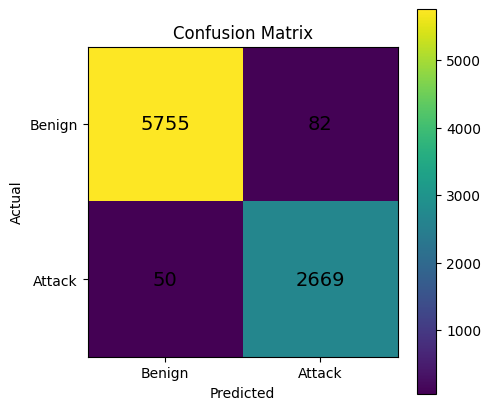

In [11]:
# ============================================================
# CELL 10
# Confusion Matrix
# ============================================================

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix")
print(cm)

plt.figure(figsize=(5,5))
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0,1], ["Benign","Attack"])
plt.yticks([0,1], ["Benign","Attack"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j],
                 ha="center",
                 va="center",
                 fontsize=14)

plt.colorbar()
plt.show()

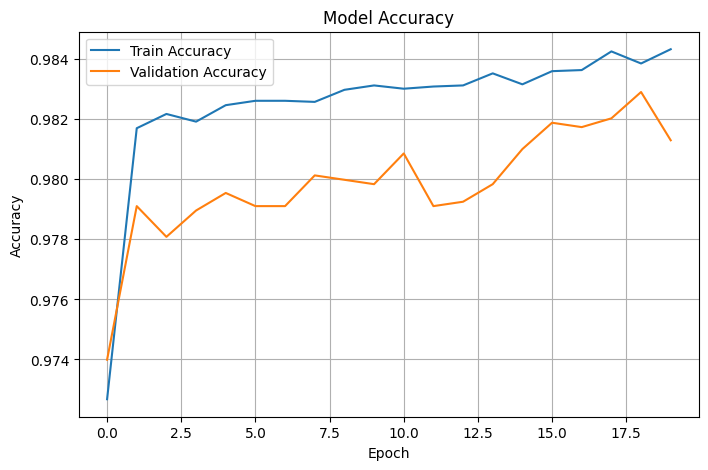

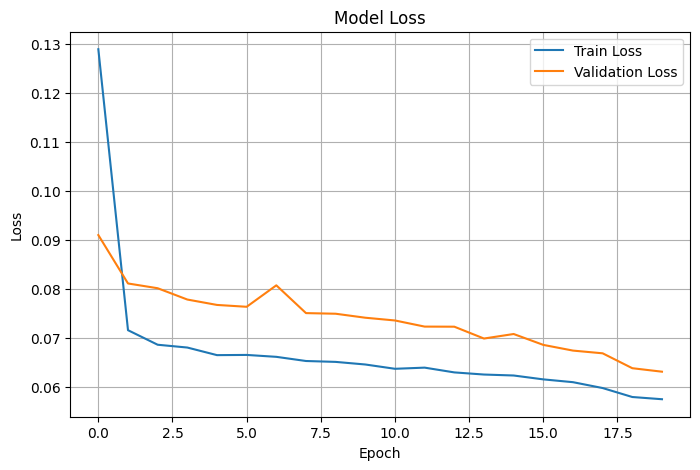

In [12]:
# ============================================================
# CELL 11
# Training History
# ============================================================

# Accuracy
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Loss
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [13]:
# ============================================================
# CELL 12
# Reshape LSTM sequences for Machine Learning models
# ============================================================

# Machine Learning models require 2D input:
# (samples, features)
# Our LSTM data is:
# (samples, 6 windows, 9 features)

# Flatten each sequence:
# 6 × 9 = 54 features

X_train_ml = X_train.reshape(X_train.shape[0], -1)
X_test_ml = X_test.reshape(X_test.shape[0], -1)

print("=" * 60)
print("Machine Learning Dataset Created")
print("=" * 60)

print("Original LSTM Shape")
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)

print("\nMachine Learning Shape")
print("X_train_ml :", X_train_ml.shape)
print("X_test_ml  :", X_test_ml.shape)

print("\nNumber of Features :", X_train_ml.shape[1])

Machine Learning Dataset Created
Original LSTM Shape
X_train : (34220, 6, 9)
X_test  : (8556, 6, 9)

Machine Learning Shape
X_train_ml : (34220, 54)
X_test_ml  : (8556, 54)

Number of Features : 54


In [14]:
# ============================================================
# CELL 13
# Logistic Regression Model
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# ----------------------------
# Create model
# ----------------------------
lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# ----------------------------
# Train
# ----------------------------
print("Training Logistic Regression...")
lr.fit(X_train_ml, y_train)

# ----------------------------
# Predict
# ----------------------------
y_pred_lr = lr.predict(X_test_ml)
y_prob_lr = lr.predict_proba(X_test_ml)[:, 1]

# ----------------------------
# Evaluation
# ----------------------------
print("=" * 60)
print("Logistic Regression Performance")
print("=" * 60)

print(f"Accuracy : {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_lr):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, y_prob_lr):.4f}")

print("\nClassification Report")
print(classification_report(y_test, y_pred_lr))

# ----------------------------
# Save results for comparison
# ----------------------------
results = []

results.append({
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred_lr),
    "Precision": precision_score(y_test, y_pred_lr),
    "Recall": recall_score(y_test, y_pred_lr),
    "F1 Score": f1_score(y_test, y_pred_lr),
    "ROC AUC": roc_auc_score(y_test, y_prob_lr)
})

Training Logistic Regression...
Logistic Regression Performance
Accuracy : 0.9832
Precision: 0.9707
Recall   : 0.9765
F1 Score : 0.9736
ROC AUC  : 0.9951

Classification Report
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      5837
           1       0.97      0.98      0.97      2719

    accuracy                           0.98      8556
   macro avg       0.98      0.98      0.98      8556
weighted avg       0.98      0.98      0.98      8556



In [15]:
# ============================================================
# CELL 14
# Random Forest Model
# ============================================================

from sklearn.ensemble import RandomForestClassifier

# ----------------------------
# Create model
# ----------------------------
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# ----------------------------
# Train
# ----------------------------
print("Training Random Forest...")
rf.fit(X_train_ml, y_train)

# ----------------------------
# Predict
# ----------------------------
y_pred_rf = rf.predict(X_test_ml)
y_prob_rf = rf.predict_proba(X_test_ml)[:, 1]

# ----------------------------
# Evaluation
# ----------------------------
print("=" * 60)
print("Random Forest Performance")
print("=" * 60)

print(f"Accuracy : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, y_prob_rf):.4f}")

print("\nClassification Report")
print(classification_report(y_test, y_pred_rf))

# ----------------------------
# Save results
# ----------------------------
results.append({
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf),
    "Recall": recall_score(y_test, y_pred_rf),
    "F1 Score": f1_score(y_test, y_pred_rf),
    "ROC AUC": roc_auc_score(y_test, y_prob_rf)
})

Training Random Forest...
Random Forest Performance
Accuracy : 0.9875
Precision: 0.9678
Recall   : 0.9937
F1 Score : 0.9806
ROC AUC  : 0.9980

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      5837
           1       0.97      0.99      0.98      2719

    accuracy                           0.99      8556
   macro avg       0.98      0.99      0.99      8556
weighted avg       0.99      0.99      0.99      8556



In [16]:
import xgboost
print(xgboost.__version__)

3.2.0


In [17]:
# ============================================================
# CELL 15
# XGBoost Model
# ============================================================

from xgboost import XGBClassifier

# ----------------------------
# Create model
# ----------------------------
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

# ----------------------------
# Train
# ----------------------------
print("Training XGBoost...")
xgb.fit(X_train_ml, y_train)

# ----------------------------
# Predict
# ----------------------------
y_pred_xgb = xgb.predict(X_test_ml)
y_prob_xgb = xgb.predict_proba(X_test_ml)[:, 1]

# ----------------------------
# Evaluation
# ----------------------------
print("=" * 60)
print("XGBoost Performance")
print("=" * 60)

print(f"Accuracy : {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_xgb):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_xgb):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, y_prob_xgb):.4f}")

print("\nClassification Report")
print(classification_report(y_test, y_pred_xgb))

# ----------------------------
# Save results
# ----------------------------
results.append({
    "Model": "XGBoost",
    "Accuracy": accuracy_score(y_test, y_pred_xgb),
    "Precision": precision_score(y_test, y_pred_xgb),
    "Recall": recall_score(y_test, y_pred_xgb),
    "F1 Score": f1_score(y_test, y_pred_xgb),
    "ROC AUC": roc_auc_score(y_test, y_prob_xgb)
})

Training XGBoost...
XGBoost Performance
Accuracy : 0.9874
Precision: 0.9694
Recall   : 0.9915
F1 Score : 0.9804
ROC AUC  : 0.9978

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      5837
           1       0.97      0.99      0.98      2719

    accuracy                           0.99      8556
   macro avg       0.98      0.99      0.99      8556
weighted avg       0.99      0.99      0.99      8556



In [18]:
# ============================================================
# CELL 16
# GRU Model
# ============================================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout

gru_model = Sequential([
    GRU(64, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

gru_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("="*60)
print("GRU Model Summary")
print("="*60)

gru_model.summary()

GRU Model Summary


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        14,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,513 (64.50 KB)

 Trainable params: 16,513 (64.50 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# ============================================================
# CELL 17
# Train GRU
# ============================================================

history_gru = gru_model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=64,
    verbose=1
)

Epoch 1/10
535/535 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9719 - loss: 0.1086 - val_accuracy: 0.9828 - val_loss: 0.0679
Epoch 2/10
535/535 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9811 - loss: 0.0719 - val_accuracy: 0.9831 - val_loss: 0.0647
Epoch 3/10
535/535 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9819 - loss: 0.0697 - val_accuracy: 0.9831 - val_loss: 0.0656
Epoch 4/10
535/535 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9817 - loss: 0.0692 - val_accuracy: 0.9836 - val_loss: 0.0642
Epoch 5/10
535/535 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9820 - loss: 0.0686 - val_accuracy: 0.9834 - val_loss: 0.0626
Epoch 6/10
535/535 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9824 - loss: 0.0671 - val_accuracy: 0.9835 - val_loss: 0.0629
Epoch 7/10
535/535 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9824 - loss: 0.0661 - val_accuracy: 0.9832 - val_loss: 0.0605
Epoch 8/10
535/535 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9828 - loss: 0.0655 - val_accuracy: 0.

In [20]:
# ============================================================
# CELL 18
# Evaluate GRU
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

y_prob_gru = gru_model.predict(X_test).flatten()
y_pred_gru = (y_prob_gru > 0.5).astype(int)

print("="*60)
print("GRU Performance")
print("="*60)

print(f"Accuracy : {accuracy_score(y_test, y_pred_gru):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_gru):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_gru):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_gru):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, y_prob_gru):.4f}")

print("\nClassification Report")
print(classification_report(y_test, y_pred_gru))

results.append({
    "Model": "GRU",
    "Accuracy": accuracy_score(y_test, y_pred_gru),
    "Precision": precision_score(y_test, y_pred_gru),
    "Recall": recall_score(y_test, y_pred_gru),
    "F1 Score": f1_score(y_test, y_pred_gru),
    "ROC AUC": roc_auc_score(y_test, y_prob_gru)
})

# Add LSTM results (from your earlier evaluation)
results.append({
    "Model": "LSTM",
    "Accuracy": 0.9857,
    "Precision": 0.9689,
    "Recall": 0.9868,
    "F1 Score": 0.9778,
    "ROC AUC": 0.9964
})

268/268 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
GRU Performance
Accuracy : 0.9854
Precision: 0.9679
Recall   : 0.9868
F1 Score : 0.9772
ROC AUC  : 0.9960

Classification Report
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      5837
           1       0.97      0.99      0.98      2719

    accuracy                           0.99      8556
   macro avg       0.98      0.99      0.98      8556
weighted avg       0.99      0.99      0.99      8556



In [21]:
# ============================================================
# CELL 19
# Final Model Comparison
# ============================================================

comparison_df = pd.DataFrame(results)

# Remove duplicates if this cell is run multiple times
comparison_df = comparison_df.drop_duplicates(subset="Model", keep="last")

# Convert to percentage
metrics = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"]

comparison_display = comparison_df.copy()

for col in metrics:
    comparison_display[col] = (comparison_display[col] * 100).round(2)

comparison_display = comparison_display.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

print("="*80)
print("FINAL MODEL COMPARISON")
print("="*80)

display(comparison_display)

FINAL MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Random Forest,98.75,96.78,99.37,98.06,99.80
1,XGBoost,98.74,96.94,99.15,98.04,99.78
2,LSTM,98.57,96.89,98.68,97.78,99.64
3,GRU,98.54,96.79,98.68,97.72,99.60
4,Logistic Regression,98.32,97.07,97.65,97.36,99.51


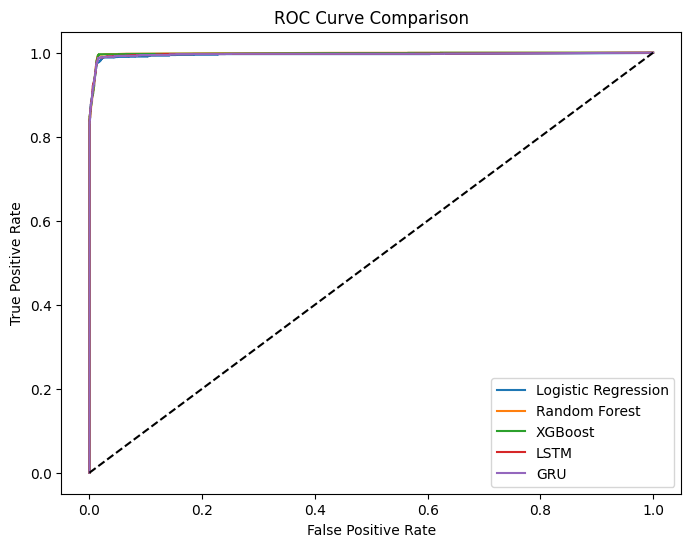

In [22]:
# ============================================================
# CELL 20
# ROC Curve Comparison
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

plt.figure(figsize=(8,6))

# Logistic Regression
fpr, tpr, _ = roc_curve(y_test, y_prob_lr)
plt.plot(fpr, tpr, label="Logistic Regression")

# Random Forest
fpr, tpr, _ = roc_curve(y_test, y_prob_rf)
plt.plot(fpr, tpr, label="Random Forest")

# XGBoost
fpr, tpr, _ = roc_curve(y_test, y_prob_xgb)
plt.plot(fpr, tpr, label="XGBoost")

# LSTM
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label="LSTM")

# GRU
fpr, tpr, _ = roc_curve(y_test, y_prob_gru)
plt.plot(fpr, tpr, label="GRU")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

In [23]:
# ============================================================
# EXPLAINABLE AI (SHAP)
# CELL 1
# ============================================================

!pip -q install shap

import shap
import numpy as np
import matplotlib.pyplot as plt

print("SHAP Version:", shap.__version__)

SHAP Version: 0.51.0


In [24]:
# ============================================================
# EXPLAINABLE AI (SHAP)
# CELL 2
# Create SHAP Explainer
# ============================================================

print("X_train_ml Shape:", X_train_ml.shape)
print("X_test_ml Shape :", X_test_ml.shape)

# ------------------------------------------------------------
# Feature names
# ------------------------------------------------------------

base_features = [
    "proto_mean",
    "service_mean",
    "conn_state_mean",
    "duration_mean",
    "orig_bytes_mean",
    "resp_bytes_mean",
    "orig_pkts_mean",
    "resp_pkts_mean",
    "flow_count"
]

sequence_length = 6

feature_names = []

for t in range(sequence_length):
    for feature in base_features:
        feature_names.append(f"{feature}_t{t+1}")

print("Total Features:", len(feature_names))

# ------------------------------------------------------------
# Create SHAP Explainer
# ------------------------------------------------------------

explainer = shap.TreeExplainer(rf)

# Explain first 500 test samples
shap_values = explainer.shap_values(X_test_ml[:500])

print("SHAP values generated successfully!")

X_train_ml Shape: (34220, 54)
X_test_ml Shape : (8556, 54)
Total Features: 54
SHAP values generated successfully!


<Figure size 1200x800 with 0 Axes>

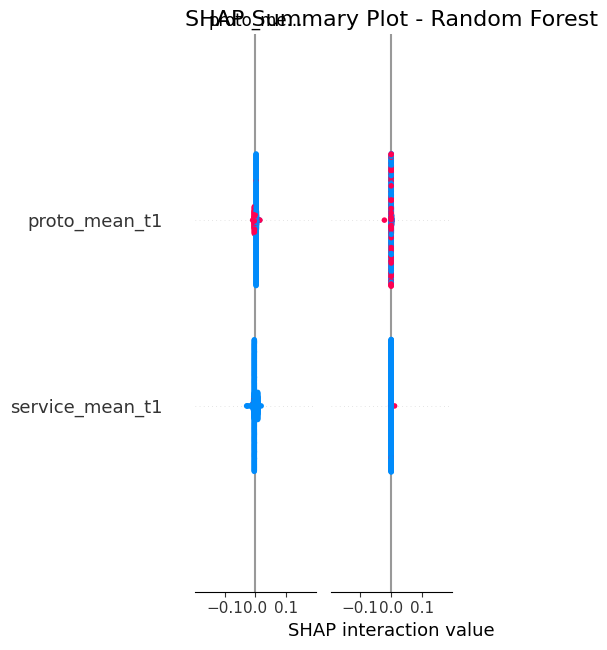

In [25]:
# ============================================================
# EXPLAINABLE AI (SHAP)
# CELL 3
# SHAP Summary Plot
# ============================================================

# For binary classification, select class 1 (Attack)
if isinstance(shap_values, list):
    shap_attack = shap_values[1]
else:
    shap_attack = shap_values

plt.figure(figsize=(12,8))

shap.summary_plot(
    shap_attack,
    X_test_ml[:500],
    feature_names=feature_names,
    show=False
)

plt.title("SHAP Summary Plot - Random Forest", fontsize=16)

plt.tight_layout()
plt.show()

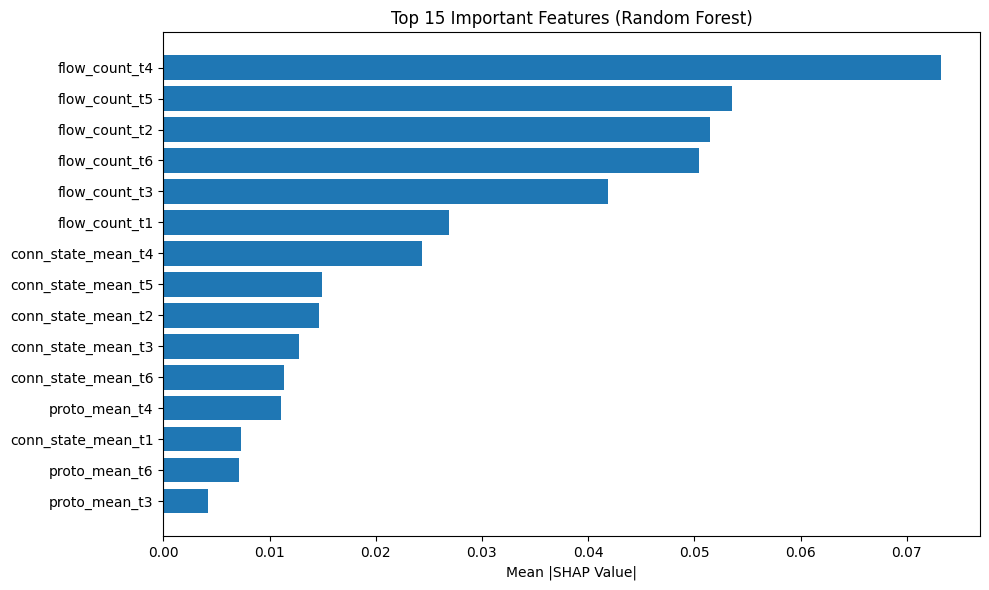

,Feature,Importance
35,flow_count_t4,0.073240
44,flow_count_t5,0.053533
17,flow_count_t2,0.051462
53,flow_count_t6,0.050452
26,flow_count_t3,0.041894
8,flow_count_t1,0.026934
29,conn_state_mean_t4,0.024400
38,conn_state_mean_t5,0.014896
11,conn_state_mean_t2,0.014636
20,conn_state_mean_t3,0.012756


In [26]:
# ============================================================
# EXPLAINABLE AI (SHAP)
# CELL 4
# Global Feature Importance (Bar Plot)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# Handle different SHAP output formats
if isinstance(shap_values, list):
    sv = shap_values[1]
elif len(shap_values.shape) == 3:
    sv = shap_values[:, :, 1]
else:
    sv = shap_values

# Mean absolute SHAP value
importance = np.abs(sv).mean(axis=0)

# Top 15 features
idx = np.argsort(importance)[::-1][:15]

plt.figure(figsize=(10,6))
plt.barh(
    [feature_names[i] for i in idx][::-1],
    importance[idx][::-1]
)

plt.xlabel("Mean |SHAP Value|")
plt.title("Top 15 Important Features (Random Forest)")
plt.tight_layout()
plt.show()

# Importance table
import pandas as pd

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values("Importance", ascending=False)

display(importance_df.head(15))

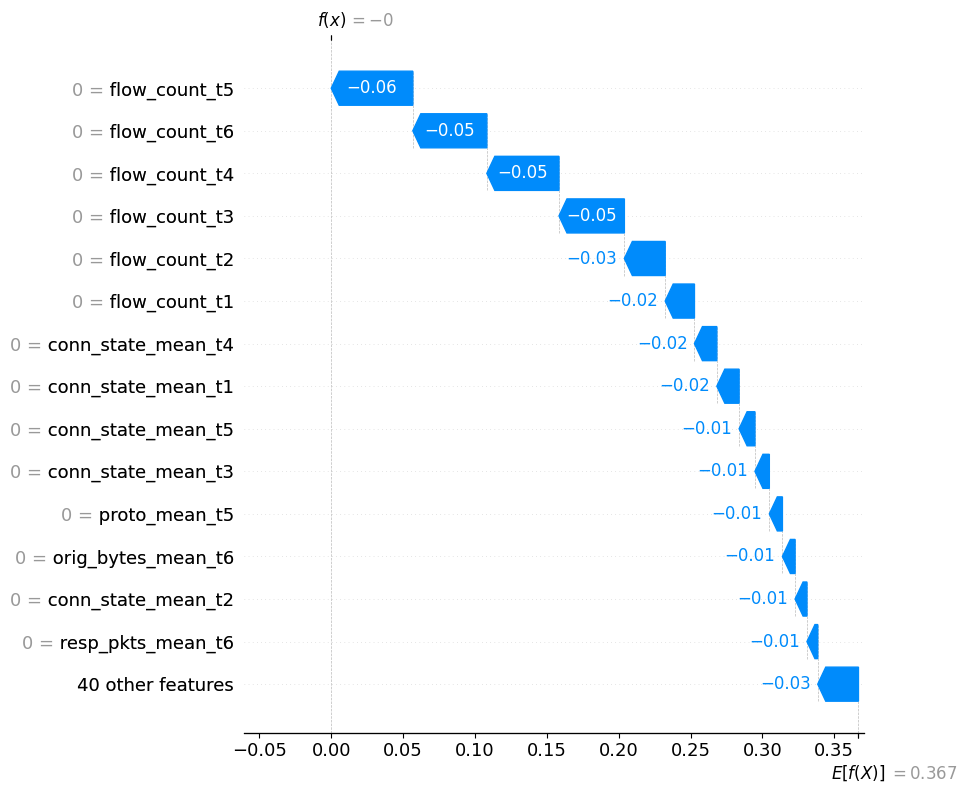

In [27]:
# ============================================================
# Create DataFrame with feature names
#EXPLAINABLE AI (SHAP)
# CELL 5 (FIXED)
# Waterfall Plot
# ============================================================

import pandas as pd

X_train_df = pd.DataFrame(X_train_ml, columns=feature_names)
X_test_df = pd.DataFrame(X_test_ml, columns=feature_names)

# Create explainer
explainer = shap.Explainer(rf, X_train_df)

# Explain first sample
shap_exp = explainer(X_test_df.iloc[[0]])

# Waterfall plot
shap.plots.waterfall(shap_exp[0, :, 1], max_display=15)

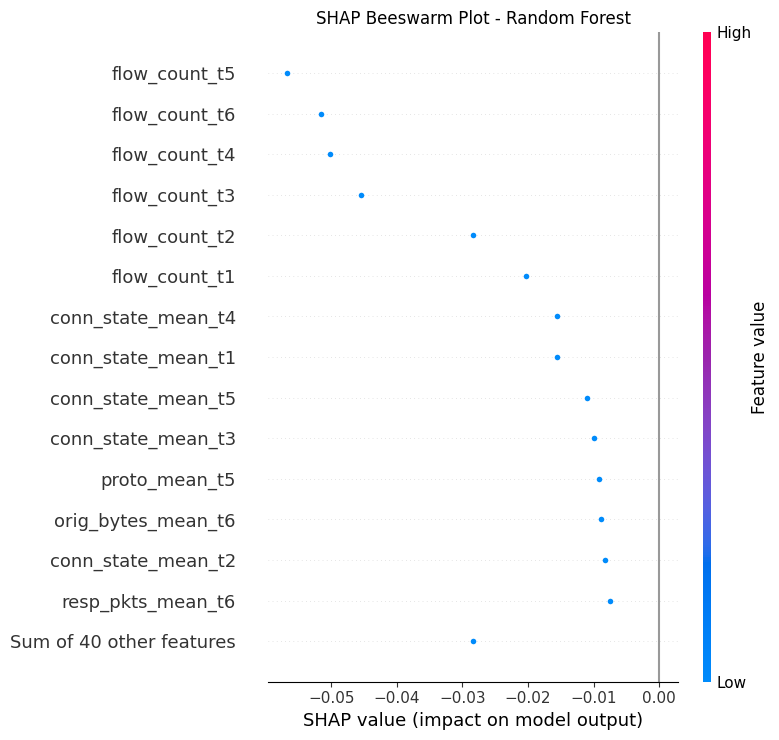

In [28]:
# ============================================================
# EXPLAINABLE AI (SHAP)
# CELL 6
# SHAP Beeswarm Plot
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

shap.plots.beeswarm(
    shap_exp[:, :, 1],
    max_display=15,
    show=False
)

plt.title("SHAP Beeswarm Plot - Random Forest")

plt.tight_layout()
plt.show()

In [29]:
# ============================================================
# EXPLAINABLE AI (SHAP)
# CELL 7
# Feature Importance Table
# ============================================================

import pandas as pd
import numpy as np

importance = np.abs(shap_exp.values[:, :, 1]).mean(axis=0)

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Mean_SHAP": importance
})

importance_df = importance_df.sort_values(
    by="Mean_SHAP",
    ascending=False
).reset_index(drop=True)

display(importance_df.head(20))

,Feature,Mean_SHAP
0,flow_count_t5,0.056756
1,flow_count_t6,0.051496
2,flow_count_t4,0.050193
3,flow_count_t3,0.045491
4,flow_count_t2,0.028405
5,flow_count_t1,0.020345
6,conn_state_mean_t4,0.015572
7,conn_state_mean_t1,0.015502
8,conn_state_mean_t5,0.011023
9,conn_state_mean_t3,0.009998


In [30]:
# ============================================================
# Save SHAP Importance
# ============================================================

importance_df.to_csv(
    "shap_feature_importance.csv",
    index=False
)

print("Saved successfully!")

Saved successfully!


In [31]:
import shap
import numpy as np
import matplotlib.pyplot as plt

print("SHAP Version:", shap.__version__)

SHAP Version: 0.51.0


In [32]:
# Background samples
background = X_train[:100]

# Samples to explain
samples = X_test[:20]

print(background.shape)
print(samples.shape)

(100, 6, 9)
(20, 6, 9)


In [33]:
# Gradient SHAP Explainer

explainer = shap.GradientExplainer(
    model,
    background
)

print("Explainer created!")

Explainer created!


In [34]:
background = X_train[:100]
samples = X_test[:20]

explainer = shap.GradientExplainer(model, background)

shap_values = explainer.shap_values(samples)

print(type(shap_values))
print(np.array(shap_values).shape)

<class 'numpy.ndarray'>
(20, 6, 9, 1)


In [35]:
# ============================================================
# EXPLAINABLE AI (SHAP)
# CELL 5
# Calculate Global Feature Importance
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Remove the last dimension
# SHAP output shape: (samples, time_steps, features, 1)
# After squeeze: (samples, time_steps, features)
# ------------------------------------------------------------
sv = shap_values.squeeze(-1)

# ------------------------------------------------------------
# Compute mean absolute SHAP values
#
# axis=(0,1)
# axis=0 -> average across all samples
# axis=1 -> average across all time windows
#
# Result:
# One importance score for each feature
# ------------------------------------------------------------
importance = np.abs(sv).mean(axis=(0,1))

# ------------------------------------------------------------
# Create Feature Importance Table
# ------------------------------------------------------------
importance_df = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": importance
})

# ------------------------------------------------------------
# Sort Features (Highest Importance First)
# ------------------------------------------------------------
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

# Display
display(importance_df)

,Feature,Importance
2,conn_state_mean,9.729604e-02
0,proto_mean,5.018746e-02
8,flow_count,1.804534e-02
1,service_mean,3.421797e-03
5,resp_bytes_mean,2.918544e-05
7,resp_pkts_mean,8.181060e-06
3,duration_mean,1.892085e-06
6,orig_pkts_mean,1.666202e-08
4,orig_bytes_mean,5.113817e-09


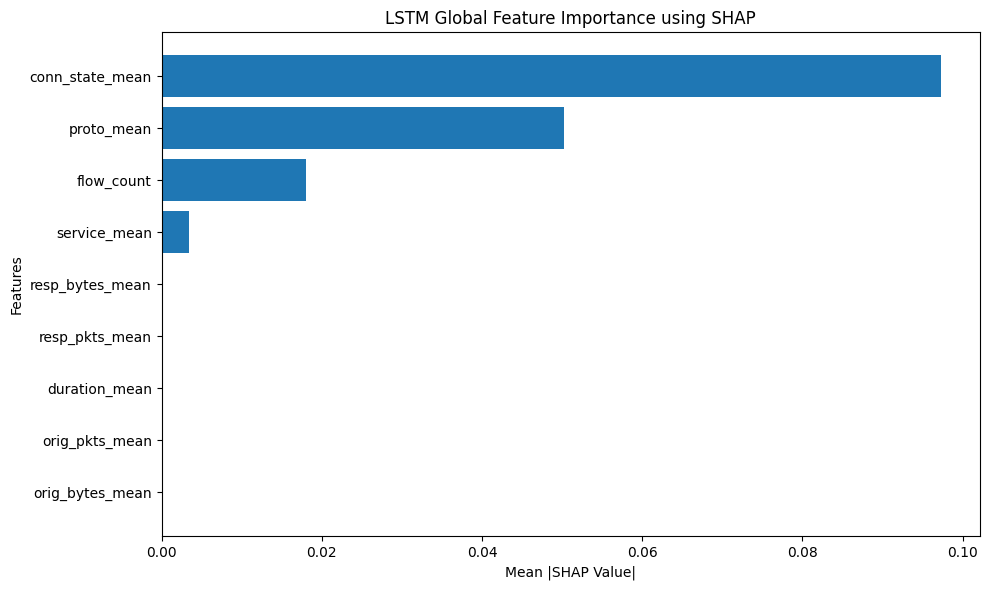

In [36]:
# ============================================================
# EXPLAINABLE AI (SHAP)
# CELL 6
# Plot Global Feature Importance
# ============================================================

# ------------------------------------------------------------
# Create Horizontal Bar Chart
#
# Shows which behavioral features contribute the most
# to the LSTM predictions.
# ------------------------------------------------------------

plt.figure(figsize=(10,6))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

# Highest importance at the top
plt.gca().invert_yaxis()

plt.xlabel("Mean |SHAP Value|")
plt.ylabel("Features")
plt.title("LSTM Global Feature Importance using SHAP")

plt.tight_layout()
plt.show()

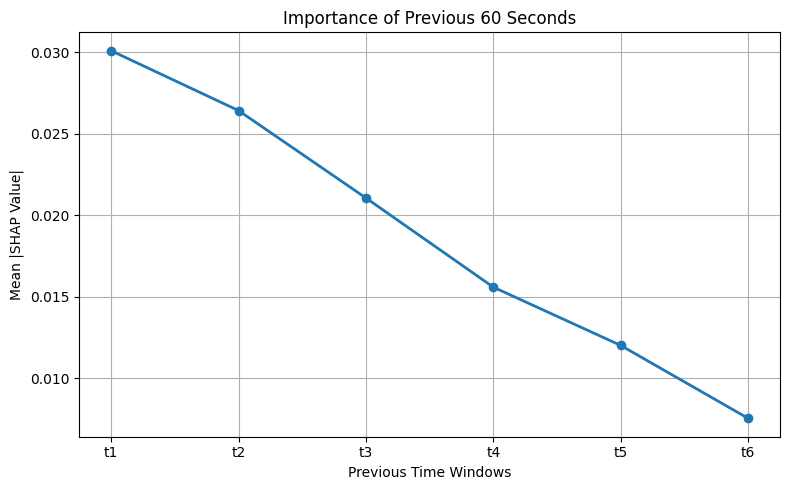

In [37]:
# ============================================================
# EXPLAINABLE AI (SHAP)
# CELL 7
# Importance of Each Time Window
# ============================================================

# ------------------------------------------------------------
# Calculate SHAP importance for each time window
#
# axis=(0,2)
# axis=0 -> average across all samples
# axis=2 -> average across all features
#
# Result:
# One importance score for each of the
# six previous 10-second windows.
# ------------------------------------------------------------

time_importance = np.abs(sv).mean(axis=(0,2))

# ------------------------------------------------------------
# Plot Time Importance
# ------------------------------------------------------------

plt.figure(figsize=(8,5))

plt.plot(
    range(1,7),
    time_importance,
    marker="o",
    linewidth=2
)

plt.xticks(
    range(1,7),
    ["t1","t2","t3","t4","t5","t6"]
)

plt.xlabel("Previous Time Windows")
plt.ylabel("Mean |SHAP Value|")

plt.title("Importance of Previous 60 Seconds")

plt.grid(True)

plt.tight_layout()
plt.show()

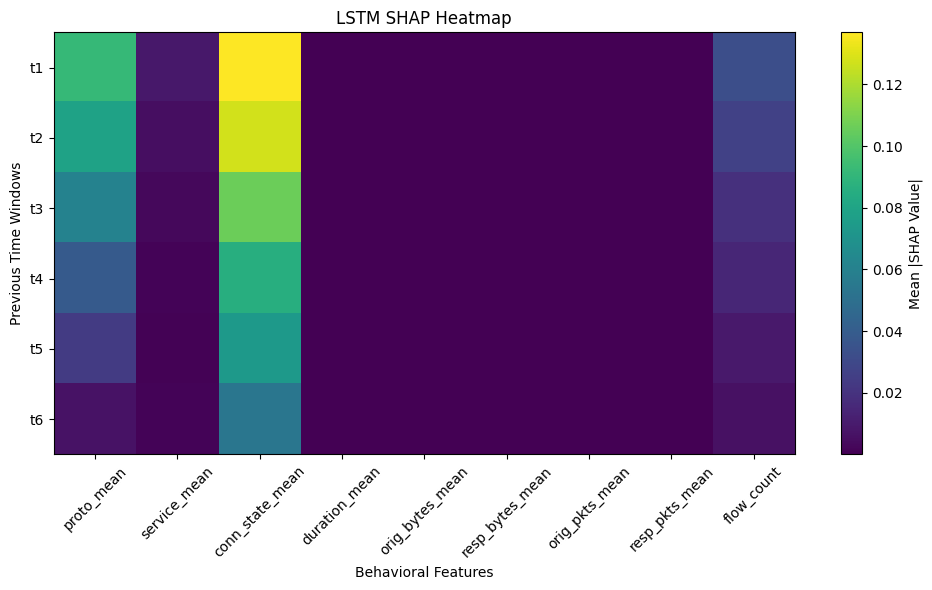

In [38]:
# ============================================================
# EXPLAINABLE AI (SHAP)
# CELL 8
# Time-Feature Importance Heatmap
# ============================================================

# ------------------------------------------------------------
# Average SHAP values across all samples
#
# Result:
# Matrix Shape = (6 Time Windows × 9 Features)
#
# Each cell represents the importance of one feature
# at one specific time window.
# ------------------------------------------------------------

heatmap = np.abs(sv).mean(axis=0)

# ------------------------------------------------------------
# Draw Heatmap
# ------------------------------------------------------------

plt.figure(figsize=(10,6))

plt.imshow(
    heatmap,
    aspect="auto",
    cmap="viridis"
)

plt.colorbar(label="Mean |SHAP Value|")

plt.xticks(
    range(len(feature_columns)),
    feature_columns,
    rotation=45
)

plt.yticks(
    range(6),
    ["t1","t2","t3","t4","t5","t6"]
)

plt.xlabel("Behavioral Features")
plt.ylabel("Previous Time Windows")

plt.title("LSTM SHAP Heatmap")

plt.tight_layout()
plt.show()